In [9]:
import glob
import os
import sys
import json
import re

import matplotlib.pyplot as plt
import pandas as pd


In [14]:
TARGET = "20260225_171412"

# Utils

In [12]:
def fetch_data(data_dir):
    files = glob.glob(os.path.join(data_dir, "*.csv"))
    if not files:
        print(f"No CSV files found in {data_dir}")
        return

    # Combine all CSVs into one dataframe
    all_data = pd.concat([pd.read_csv(f) for f in files])
    return all_data

def process_ddp_results(data_dirs, metrics=None):
    """
    Fetches data from multiple directories, combines them, 
    and calculates mean performance metrics.
    """
    if metrics is None:
        metrics = ["fwd_time", "bwd_time", "opt_time", "total_time"]

    # 1. Fetch and Combine
    # Assumes fetch_data is a pre-defined function that returns a DataFrame
    all_dfs = [fetch_data(d) for d in data_dirs]
    combined_df = pd.concat(all_dfs, axis=0, ignore_index=True)
    
    # 2. Sort for consistent plotting later
    combined_df = combined_df.sort_values(by="num_params")
    
    # 3. Aggregate to Summary
    # Grouping by node and configuration to get the average timing per metric
    summary = (
        combined_df.groupby(["node_id", "num_params", "grad_bucket"])[metrics]
        .mean()
        .reset_index()
    )
    
    return combined_df, summary


def plot_node_performance_1(summary, node_id):
    """
    Plots performance metrics comparing Standard DDP vs Bucket View 
    for a specific node_id across varying parameter counts.
    """
    # 1. Filter and split data
    node_df = summary[summary['node_id'] == node_id]
    no_gb = node_df[node_df['grad_bucket'] == 0].sort_values('num_params')
    with_gb = node_df[node_df['grad_bucket'] == 1].sort_values('num_params')

    # 2. Define metrics to plot
    plot_map = {
        "fwd_time": "Forward Pass Time",
        "bwd_time": "Backward Pass (Sync) Time",
        "opt_time": "Optimizer Step Time",
        "total_time": "Total Completion Time"
    }

    # 3. Initialize Grid
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for ax, (metric, title) in zip(axes, plot_map.items()):
        # Plot both series
        ax.plot(no_gb['num_params'], no_gb[metric], 'o-', label='Standard DDP ($gb=0$)')
        ax.plot(with_gb['num_params'], with_gb[metric], 's--', label='Bucket View ($gb=1$)')

        # Formatting
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f'{title} (Node {node_id})', fontsize=12)
        ax.set_xlabel('Number of Parameters')
        ax.set_ylabel('Time (s)')
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

def plot_improvement_percentage(summary, node_id):
    """
    Plots the percentage improvement of Bucket View (gb=1) over Standard DDP (gb=0)
    across 4 subplots for a specific node_id.
    """
    # 1. Filter and Pivot
    df = summary[summary['node_id'] == node_id].copy()
    metrics = ["fwd_time", "bwd_time", "opt_time", "total_time"]
    pivoted = df.pivot(index='num_params', columns='grad_bucket', values=metrics)

    # 2. Map metrics to readable titles
    plot_map = {
        "fwd_time": "Forward Pass Improvement",
        "bwd_time": "Backward Pass (Sync) Improvement",
        "opt_time": "Optimizer Step Improvement",
        "total_time": "Total Completion Improvement"
    }

    # 3. Create 2x2 Grid
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for i, (metric, title) in enumerate(plot_map.items()):
        ax = axes[i]
        
        # Calculate % Improvement: ((Base - Improved) / Base) * 100
        base = pivoted[metric][0]
        improved = pivoted[metric][1]
        pct_improvement = ((base - improved) / base) * 100

        # Plot as Bar
        pct_improvement.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black', alpha=0.8)

        # Formatting
        ax.set_title(f"{title} (Node {node_id})", fontsize=13)
        ax.set_ylabel("Improvement (%)")
        ax.set_xlabel("Number of Parameters")
        ax.axhline(0, color='red', linewidth=1, linestyle='--') # Red line at 0 for "No Change"
        ax.grid(axis='y', linestyle='-', alpha=0.2)
        
        # Make x-labels readable
        ax.set_xticklabels(pct_improvement.index, rotation=45)

    plt.tight_layout()
    plt.show()

LINE_PREFIX = "bms#: "

def _extract_gb_param(filename: str):
    """
    Extract gb and param from filenames like:
      stdout-node-0-gb-1-param-8388608.log
      profile-node-0-gb-0-param-16777216.log
    """
    m = re.search(r"-gb-(\d+)-param-(\d+)\-data-(\d+)\.log$", filename)
    if not m:
        return None
    return int(m.group(1)), int(m.group(2))

def _parse_bms_event_line(line: str):
    """
    Parse:
      bms#: name,start,ts
      bms#: name,end,ts
    Return (name, ph, ts_us) or None.
    """
    line = line.strip()
    if not line.startswith(LINE_PREFIX):
        return None

    # fast reject
    if ("start" not in line) and ("end" not in line):
        return None

    parts = line[len(LINE_PREFIX):].split(",")
    if len(parts) < 3:
        return None

    name = parts[0].strip()
    phase_type = parts[1].strip()
    ts_raw = parts[2].strip()

    if phase_type not in ("start", "end"):
        return None

    # Convert to microseconds:
    # - if float => seconds -> us
    # - else int => nanoseconds -> us
    try:
        ts_us = float(ts_raw) * 1_000_000.0 if "." in ts_raw else int(ts_raw) / 1_000.0
    except ValueError:
        return None

    ph = "B" if phase_type == "start" else "E"
    return name, ph, ts_us

def combine_trace_files(log_dir: str):
    # Collect only stdout- and profile- logs
    paths = glob.glob(os.path.join(log_dir, "stdout-*.log")) + glob.glob(os.path.join(log_dir, "profile-*.log"))

    # Group by param only: param -> {"stdout": {gb: path}, "profile": {gb: path}}
    groups = {}
    for p in paths:
        fn = os.path.basename(p)
        info = _extract_gb_param(fn)
        if info is None:
            continue
        gb, param = info

        g = groups.setdefault(param, {"stdout": {}, "profile": {}})
        if fn.startswith("stdout-"):
            g["stdout"][gb] = p
        elif fn.startswith("profile-"):
            g["profile"][gb] = p

    # Process each param group
    num_writes = 0
    for param, g in sorted(groups.items(), key=lambda x: x[0]):
        # Need exactly 2 stdout (gb=0,1) and 2 profile (gb=0,1) => total 4
        if len(g["stdout"]) != 2 or len(g["profile"]) != 2:
            continue

        events = []
        # Parse line-by-line for all 4 files
        for kind in ("stdout", "profile"):
            for gb, path in g[kind].items():
                with open(path, "r") as f:
                    for line in f:
                        parsed = _parse_bms_event_line(line)
                        if parsed is None:
                            continue
                        name, ph, ts = parsed
                        events.append({
                            "name": name,
                            "ph": ph,
                            "ts": ts,   # absolute for now
                            "pid": gb,
                            "tid": gb,
                        })

        if not events:
            continue

        # # Sort by ts, normalize
        # events.sort(key=lambda e: e["ts"])
        # first_ts = events[0]["ts"]
        # for e in events:
        #     e["ts"] -= first_ts
        # Sort by ts
        events.sort(key=lambda e: e["ts"])

        # Per-gb first_ts (gb is stored as pid/tid)
        first_ts_by_gb = {}
        for e in events:
            gb = e["pid"]
            if gb not in first_ts_by_gb:
                first_ts_by_gb[gb] = e["ts"]

        # Normalize each row by its gb's first_ts
        for e in events:
            gb = e["pid"]
            e["ts"] -= first_ts_by_gb[gb]

        out_path = os.path.join(log_dir, f"combined-trace-params-{param}.json")
        with open(out_path, "w") as f:
            json.dump(events, f, indent=2)

        print(f"Wrote {out_path} (events={len(events)})")
        num_writes += 1
    print(f"Total writes = {num_writes}")

# Overall

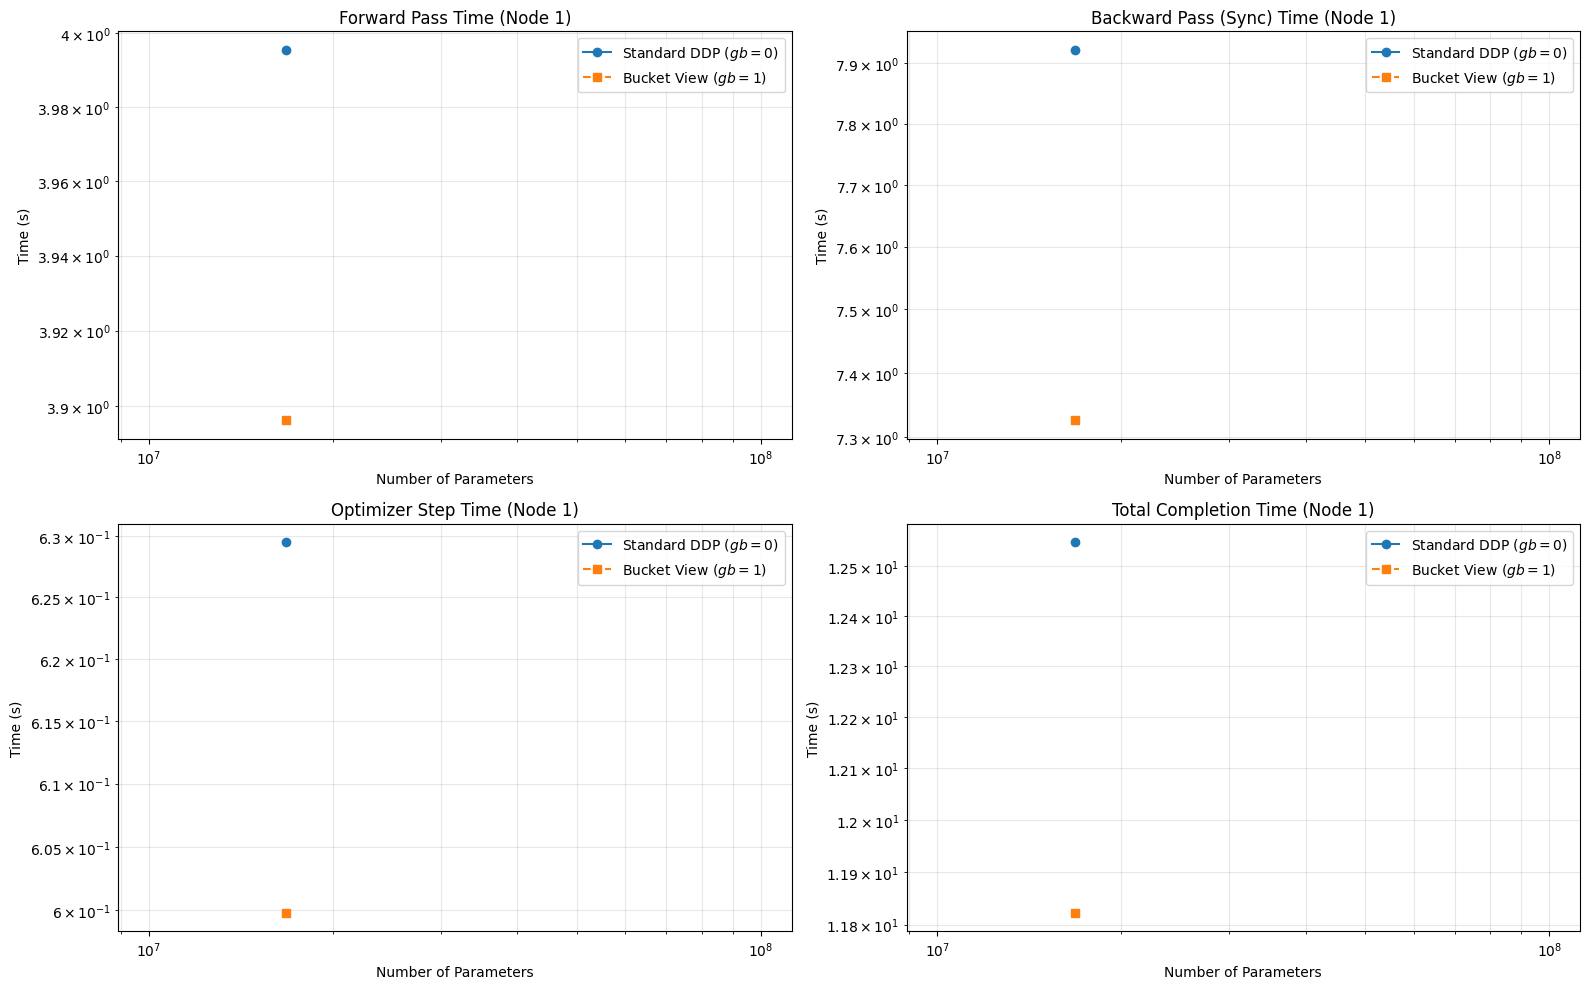

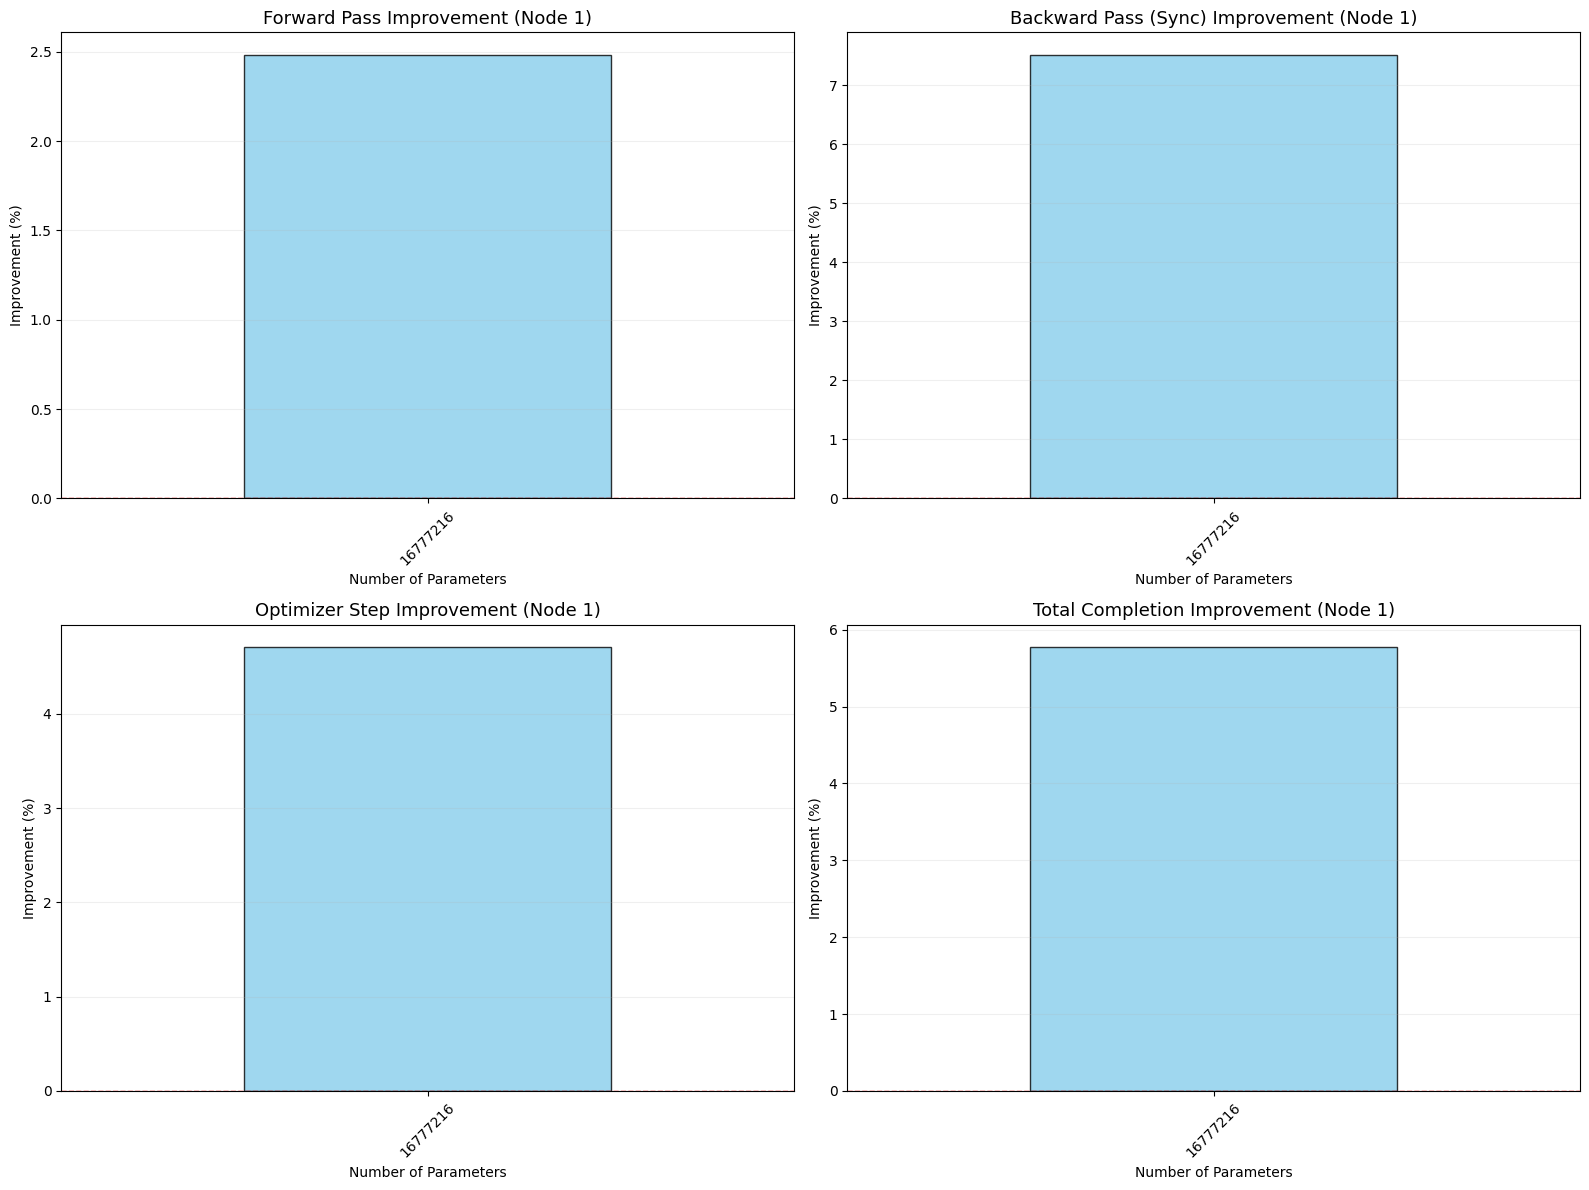

In [13]:
all_data, summary = process_ddp_results([f'./data/{TARGET}/'])
plot_node_performance_1(summary, 1)
plot_improvement_percentage(summary, 1)

# Timeseries analysis

In [8]:
combine_trace_files(f'./data/{TARGET}/')

Wrote ./data/20260224_164935/combined-trace-params-4194304.json (events=638376)
Wrote ./data/20260224_164935/combined-trace-params-8388608.json (events=1193748)
Wrote ./data/20260224_164935/combined-trace-params-16777216.json (events=2291968)
Total writes = 3
